In [1]:
# Cell 1: Google Drive mount
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Cell 2: rasterio installation
# rasterio reads georeferenced raster files (GeoTIFF)
!pip install -q rasterio

In [23]:
# Cell 3: Repository update and package import path
import sys
from pathlib import Path

REPO_URL = "https://github.com/Prhm93/floodfm-sen1floods11.git"
REPO_DIR = Path("/content/floodfm-sen1floods11")

# Clone on the first run in a session; pull the latest commits on later runs
if REPO_DIR.exists():
    !git -C {REPO_DIR} pull
else:
    !git clone {REPO_URL} {REPO_DIR}

# The src folder is added to the Python search path, so that "import floodfm" finds the package
if str(REPO_DIR / "src") not in sys.path:
    sys.path.insert(0, str(REPO_DIR / "src"))

Already up to date.


What Cell 4 does: it tests the module. It counts the chips in each split. Then it checks all 446 chips for pixels that have a label but no radar data.

In [4]:
# Cell 4: Data module test and missing-radar check
import numpy as np
from floodfm.data import read_split, read_chip

DATA_ROOT = Path("/content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/data/sen1floods11")
SPLITS = ["train", "valid", "test", "bolivia"]

# Number of chips in each official split
splits = {name: read_split(DATA_ROOT, name) for name in SPLITS}
for name, ids in splits.items():
    print(f"{name}: {len(ids)} chips")

# Pixels with a label (0 or 1) but without radar data (NaN in VH), counted for each split
print()
for name, ids in splits.items():
    scored, no_radar = 0, 0
    for chip_id in ids:
        chip = read_chip(DATA_ROOT, chip_id)
        has_label = chip["label"] != -1
        scored += int(has_label.sum())
        no_radar += int((has_label & ~np.isfinite(chip["s1"][1])).sum())
    print(f"{name}: scored pixels = {scored}, scored pixels without radar = {no_radar}")

train: 252 chips
valid: 89 chips
test: 90 chips
bolivia: 15 chips

train: scored pixels = 57303407, scored pixels without radar = 24150
valid: scored pixels = 20294725, scored pixels without radar = 20571
test: scored pixels = 20517367, scored pixels without radar = 73408
bolivia: scored pixels = 2867815, scored pixels without radar = 43381


**What Cell 5 does:**

It reads the VH band of one chip.
It calculates the Otsu threshold from the pixels that have radar data.
It calls a pixel "water" if the VH value is less than the threshold.
It compares the prediction with the label. It counts the four pixel results (section 5 of the lesson).

In [5]:
# Cell 5: Otsu threshold on the VH band of one chip
from skimage.filters import threshold_otsu

CHIP_ID = "Bolivia_103757"
chip = read_chip(DATA_ROOT, CHIP_ID)
vh = chip["s1"][1]
label = chip["label"]
has_radar = np.isfinite(vh)

# Otsu threshold computed only from pixels with radar data
threshold = threshold_otsu(vh[has_radar])

# Prediction: 1 (water) where VH is below the threshold; 0 elsewhere, including pixels without radar data
pred = np.zeros(label.shape, dtype="uint8")
pred[has_radar & (vh < threshold)] = 1

# Pixel results on scored pixels only (label 0 or 1)
scored = label != -1
tp = int((scored & (pred == 1) & (label == 1)).sum())
fp = int((scored & (pred == 1) & (label == 0)).sum())
fn = int((scored & (pred == 0) & (label == 1)).sum())
tn = int((scored & (pred == 0) & (label == 0)).sum())

print(f"Otsu threshold: {threshold:.2f} dB")
print(f"TP = {tp}, FP = {fp}, FN = {fn}, TN = {tn}")
print(f"IoU = {tp / (tp + fp + fn):.3f}")
print(f"F1  = {2 * tp / (2 * tp + fp + fn):.3f}")

Otsu threshold: -20.45 dB
TP = 30468, FP = 2745, FN = 4894, TN = 49970
IoU = 0.800
F1  = 0.889


**What Cell 6 does:** it draws three panels. These are the VH band, the label and the error picture. The error picture uses the colours in section 5 of the lesson. The cell saves the figure to Drive.

Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/figures/stage2_otsu_errors_Bolivia_103757.png


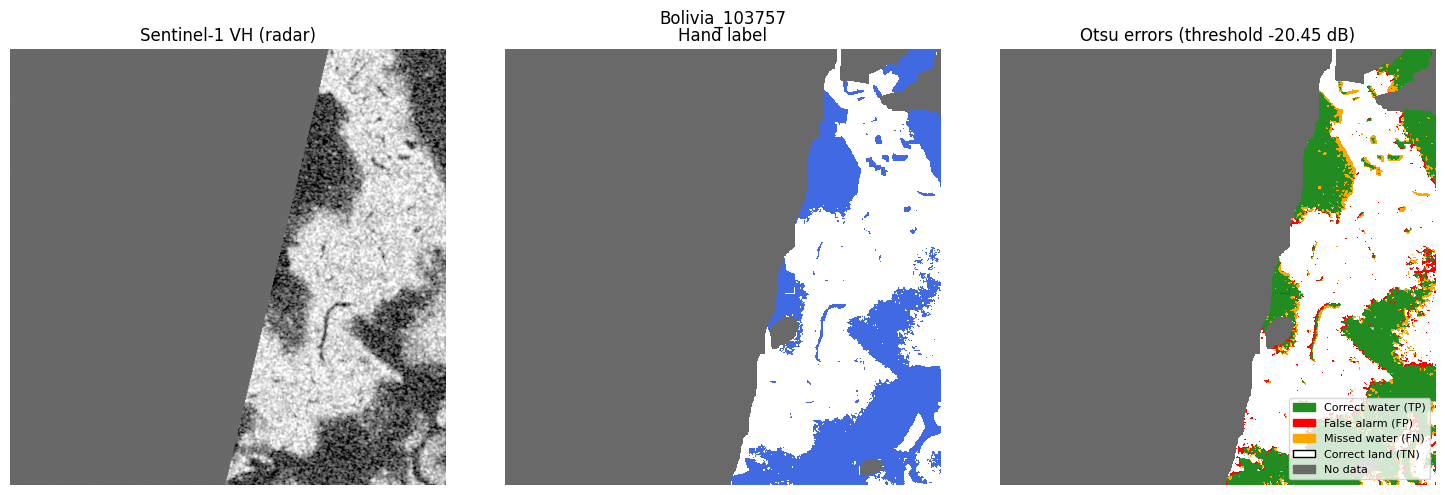

In [6]:
# Cell 6: Error picture for the Otsu prediction of one chip
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

FIG_DIR = Path("/content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/figures")

def stretch(band, low=2, high=98):
    """Rescales a band to the 0-1 range between its 2nd and 98th percentiles; NaN values are ignored. Display only."""
    lo, hi = np.nanpercentile(band, [low, high])
    return np.clip((band - lo) / (hi - lo), 0, 1)

# Error classes: 0 no data, 1 correct land (TN), 2 correct water (TP), 3 false alarm (FP), 4 missed water (FN)
errors = np.zeros(label.shape, dtype="uint8")
errors[scored & (pred == 0) & (label == 0)] = 1
errors[scored & (pred == 1) & (label == 1)] = 2
errors[scored & (pred == 1) & (label == 0)] = 3
errors[scored & (pred == 0) & (label == 1)] = 4
error_cmap = ListedColormap(["dimgrey", "white", "forestgreen", "red", "orange"])

# Grey colour map with NaN shown in dim grey; label colours in value order -1, 0, 1
radar_cmap = plt.cm.gray.copy()
radar_cmap.set_bad("dimgrey")
label_cmap = ListedColormap(["dimgrey", "white", "royalblue"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(stretch(vh), cmap=radar_cmap)
axes[0].set_title("Sentinel-1 VH (radar)")
axes[1].imshow(label, cmap=label_cmap, vmin=-1, vmax=1, interpolation="nearest")
axes[1].set_title("Hand label")
axes[2].imshow(errors, cmap=error_cmap, vmin=0, vmax=4, interpolation="nearest")
axes[2].set_title(f"Otsu errors (threshold {threshold:.2f} dB)")
axes[2].legend(
    handles=[Patch(color="forestgreen", label="Correct water (TP)"),
             Patch(color="red", label="False alarm (FP)"),
             Patch(color="orange", label="Missed water (FN)"),
             Patch(facecolor="white", edgecolor="black", label="Correct land (TN)"),
             Patch(color="dimgrey", label="No data")],
    loc="lower right", fontsize=8,
)
for ax in axes:
    ax.axis("off")

fig.suptitle(CHIP_ID)
plt.tight_layout()
out_path = FIG_DIR / f"stage2_otsu_errors_{CHIP_ID}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved:", out_path)
plt.show()

In [8]:
# Cell 7: Otsu baseline on all splits; counts and scores saved to Drive
import json
from datetime import datetime
from floodfm.baselines import otsu_vh
from floodfm.metrics import confusion_counts, add_counts, scores

RESULTS_PATH = Path("/content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/results/otsu_vh.json")

# Short ID of the code version that produced the results
commit = !git -C {REPO_DIR} rev-parse --short HEAD

results = {
    "method": "otsu_vh",
    "description": "Otsu threshold on the Sentinel-1 VH band, one threshold per chip; no smoothing; pixels without radar predicted as not water",
    "created": datetime.now().isoformat(timespec="seconds"),
    "code_commit": commit[0],
    "splits": {},
}

for split in SPLITS:
    split_total, event_totals, chips = {}, {}, {}
    for chip_id in read_split(DATA_ROOT, split):
        chip = read_chip(DATA_ROOT, chip_id)
        pred, threshold = otsu_vh(chip["s1"])
        counts = confusion_counts(pred, chip["label"])
        chips[chip_id] = {**counts, "threshold_db": threshold}
        add_counts(split_total, counts)
        add_counts(event_totals.setdefault(chip_id.split("_")[0], {}), counts)

    # Scores from counts summed over the whole split and over each event
    results["splits"][split] = {
        "overall": {**split_total, **scores(split_total)},
        "events": {event: {**c, **scores(c)} for event, c in sorted(event_totals.items())},
        "chips": chips,
    }
    s = results["splits"][split]["overall"]
    print(f"{split}: IoU = {s['iou']:.3f}, F1 = {s['f1']:.3f}, water share = {s['water_share']:.3f}")

RESULTS_PATH.write_text(json.dumps(results, indent=2))
print("Saved:", RESULTS_PATH)

train: IoU = 0.187, F1 = 0.315, water share = 0.095
valid: IoU = 0.220, F1 = 0.361, water share = 0.110
test: IoU = 0.230, F1 = 0.374, water share = 0.125
bolivia: IoU = 0.403, F1 = 0.575, water share = 0.159
Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/results/otsu_vh.json


What Cell 8 does: it reads the results file back from Drive and shows the scores for each event. This follows the rule of the brief: each number comes from a saved file.

In [9]:
# Cell 8: Per-event Otsu scores, read back from the saved results file
import pandas as pd

saved = json.loads(RESULTS_PATH.read_text())
rows = []
for split in ["test", "bolivia"]:
    for event, s in saved["splits"][split]["events"].items():
        rows.append({
            "split": split,
            "event": event,
            "iou": s["iou"],
            "f1": s["f1"],
            "water_share": s["water_share"],
            "scored_pixels": s["scored_pixels"],
        })

print(pd.DataFrame(rows).round(3).to_string(index=False))

  split     event   iou    f1  water_share  scored_pixels
   test     Ghana 0.109 0.197        0.080        2133857
   test     India 0.386 0.557        0.213        3224168
   test    Mekong 0.311 0.475        0.145        1453220
   test   Nigeria 0.299 0.460        0.162         760104
   test  Pakistan 0.206 0.341        0.180        1107924
   test  Paraguay 0.167 0.286        0.073        3306197
   test   Somalia 0.161 0.277        0.065        1326678
   test     Spain 0.413 0.585        0.238        1481713
   test Sri-Lanka 0.226 0.369        0.185        2053984
   test       USA 0.078 0.145        0.031        3669522
bolivia   Bolivia 0.403 0.575        0.159        2867815


Cell 9: check the reason

What Cell 9 does:

1. It compares the false alarms (FP) with the missed water (FN).
2. It finds the test chips with less than 1% water. It measures what share of all false alarms comes from those chips.
3. It shows the range of the Otsu thresholds.

All numbers come from the saved results file.

In [10]:
# Cell 9: Error balance and Otsu thresholds, read from the saved results file
for split in ["test", "bolivia"]:
    o = saved["splits"][split]["overall"]
    print(f"{split}: TP = {o['tp']:,}  FP = {o['fp']:,}  FN = {o['fn']:,}  |  FP / FN = {o['fp'] / o['fn']:.1f}")

# Per-chip table for the test split: water share in the label and share predicted as water
chips = pd.DataFrame.from_dict(saved["splits"]["test"]["chips"], orient="index")
scored = chips["tp"] + chips["fp"] + chips["fn"] + chips["tn"]
chips["water_share"] = (chips["tp"] + chips["fn"]) / scored
chips["predicted_share"] = (chips["tp"] + chips["fp"]) / scored

# Share of all false alarms that come from nearly dry chips (less than 1% water)
dry = chips[chips["water_share"] < 0.01]
print(f"\nTest chips with less than 1% water: {len(dry)} of {len(chips)}")
print(f"False alarms on these chips: {dry['fp'].sum():,} of {chips['fp'].sum():,} "
      f"({100 * dry['fp'].sum() / chips['fp'].sum():.0f}%)")
print(f"Mean share predicted as water on these chips: {100 * dry['predicted_share'].mean():.1f}%")

# Range of the per-chip Otsu thresholds in the test split (dB)
print("\nOtsu thresholds on test chips (dB):")
print(chips["threshold_db"].describe().round(2))

test: TP = 1,832,911  FP = 5,407,057  FN = 733,190  |  FP / FN = 7.4
bolivia: TP = 389,918  FP = 512,213  FN = 64,946  |  FP / FN = 7.9

Test chips with less than 1% water: 28 of 90
False alarms on these chips: 2,581,480 of 5,407,057 (48%)
Mean share predicted as water on these chips: 39.7%

Otsu thresholds on test chips (dB):
count    89.00
mean    -18.60
std       3.12
min     -27.45
25%     -20.06
50%     -17.80
75%     -16.53
max     -13.26
Name: threshold_db, dtype: float64


In [14]:
# Cell 10: VH histograms of water and land pixels in the training split
# Candidate thresholds every 0.1 dB from -50 to +10 dB
BIN_EDGES = np.arange(-50.0, 10.01, 0.1)
water_hist = np.zeros(len(BIN_EDGES) - 1, dtype="int64")
land_hist = np.zeros(len(BIN_EDGES) - 1, dtype="int64")
water_no_radar = 0

for chip_id in read_split(DATA_ROOT, "train"):
    chip = read_chip(DATA_ROOT, chip_id)
    vh, label = chip["s1"][1], chip["label"]
    has_radar = np.isfinite(vh)
    # Values outside the range are clipped into the first or last bin, so that no pixel is lost
    vh_clipped = np.clip(vh, BIN_EDGES[0], BIN_EDGES[-1] - 0.001)
    water_hist += np.histogram(vh_clipped[has_radar & (label == 1)], bins=BIN_EDGES)[0]
    land_hist += np.histogram(vh_clipped[has_radar & (label == 0)], bins=BIN_EDGES)[0]
    # Water pixels without radar are always predicted as not water, so they always count as FN
    water_no_radar += int((~has_radar & (label == 1)).sum())

print(f"Training water pixels with radar: {water_hist.sum():,}")
print(f"Training land pixels with radar:  {land_hist.sum():,}")
print(f"Training water pixels without radar: {water_no_radar:,}")

Training water pixels with radar: 5,446,678
Training land pixels with radar:  51,832,579
Training water pixels without radar: 357


Best training threshold: -23.6 dB
Training IoU at this threshold: 0.465
Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/figures/stage2_fixed_threshold_curve.png


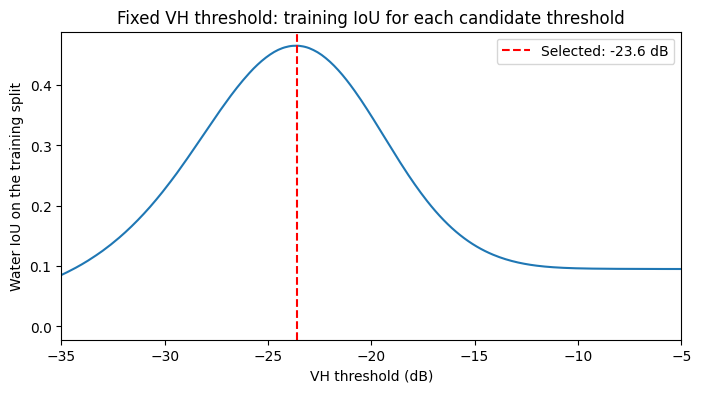

In [15]:
# Cell 11: Training IoU for each candidate threshold, and selection of the best threshold
# For threshold t = BIN_EDGES[k + 1], every pixel in bins 0..k has VH < t and is predicted as water
thresholds = BIN_EDGES[1:]
tp = np.cumsum(water_hist)
fp = np.cumsum(land_hist)
fn = (water_hist.sum() - tp) + water_no_radar
train_iou = tp / (tp + fp + fn)

best = int(np.argmax(train_iou))
BEST_THRESHOLD = round(float(thresholds[best]), 1)
print(f"Best training threshold: {BEST_THRESHOLD} dB")
print(f"Training IoU at this threshold: {train_iou[best]:.3f}")

# Training IoU against the threshold, with the selected threshold marked
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, train_iou)
ax.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"Selected: {BEST_THRESHOLD} dB")
ax.set_xlim(-35, -5)
ax.set_xlabel("VH threshold (dB)")
ax.set_ylabel("Water IoU on the training split")
ax.set_title("Fixed VH threshold: training IoU for each candidate threshold")
ax.legend()
out_path = FIG_DIR / "stage2_fixed_threshold_curve.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("Saved:", out_path)
plt.show()

In [16]:
# Cell 12: Fixed-threshold baseline on all splits; counts and scores saved to Drive
import importlib
import subprocess
import floodfm.baselines
importlib.reload(floodfm.baselines)
from floodfm.baselines import fixed_vh

RESULTS_DIR = Path("/content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/results")
commit = subprocess.run(["git", "-C", str(REPO_DIR), "rev-parse", "--short", "HEAD"],
                        capture_output=True, text=True).stdout.strip()

fixed_results = {
    "method": "fixed_vh",
    "description": "One fixed threshold on the Sentinel-1 VH band for all chips, selected by best water IoU on the training split; pixels without radar predicted as not water",
    "threshold_db": BEST_THRESHOLD,
    "train_iou_at_selection": float(train_iou[best]),
    "created": datetime.now().isoformat(timespec="seconds"),
    "code_commit": commit,
    "splits": {},
}

for split in SPLITS:
    split_total, event_totals, chips = {}, {}, {}
    for chip_id in read_split(DATA_ROOT, split):
        chip = read_chip(DATA_ROOT, chip_id)
        counts = confusion_counts(fixed_vh(chip["s1"], BEST_THRESHOLD), chip["label"])
        chips[chip_id] = counts
        add_counts(split_total, counts)
        add_counts(event_totals.setdefault(chip_id.split("_")[0], {}), counts)

    fixed_results["splits"][split] = {
        "overall": {**split_total, **scores(split_total)},
        "events": {event: {**c, **scores(c)} for event, c in sorted(event_totals.items())},
        "chips": chips,
    }
    s = fixed_results["splits"][split]["overall"]
    print(f"{split}: IoU = {s['iou']:.3f}, F1 = {s['f1']:.3f}, water share = {s['water_share']:.3f}")

out_path = RESULTS_DIR / "fixed_vh.json"
out_path.write_text(json.dumps(fixed_results, indent=2))
print("Saved:", out_path)

train: IoU = 0.465, F1 = 0.635, water share = 0.095
valid: IoU = 0.492, F1 = 0.659, water share = 0.110
test: IoU = 0.524, F1 = 0.688, water share = 0.125
bolivia: IoU = 0.531, F1 = 0.694, water share = 0.159
Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/results/fixed_vh.json


In [17]:
# Cell 13: Otsu and fixed-threshold scores side by side, read from the saved results files
otsu = json.loads((RESULTS_DIR / "otsu_vh.json").read_text())
fixed = json.loads((RESULTS_DIR / "fixed_vh.json").read_text())

rows = []
for split in ["test", "bolivia"]:
    groups = ["ALL"] + sorted(otsu["splits"][split]["events"])
    for group in groups:
        o = otsu["splits"][split]["overall"] if group == "ALL" else otsu["splits"][split]["events"][group]
        f = fixed["splits"][split]["overall"] if group == "ALL" else fixed["splits"][split]["events"][group]
        rows.append({
            "split": split,
            "group": group,
            "water_share": o["water_share"],
            "otsu_iou": o["iou"],
            "fixed_iou": f["iou"],
            "otsu_f1": o["f1"],
            "fixed_f1": f["f1"],
        })

print(pd.DataFrame(rows).round(3).to_string(index=False))

  split     group  water_share  otsu_iou  fixed_iou  otsu_f1  fixed_f1
   test       ALL        0.125     0.230      0.524    0.374     0.688
   test     Ghana        0.080     0.109      0.453    0.197     0.624
   test     India        0.213     0.386      0.593    0.557     0.745
   test    Mekong        0.145     0.311      0.724    0.475     0.840
   test   Nigeria        0.162     0.299      0.708    0.460     0.829
   test  Pakistan        0.180     0.206      0.150    0.341     0.261
   test  Paraguay        0.073     0.167      0.397    0.286     0.569
   test   Somalia        0.065     0.161      0.256    0.277     0.408
   test     Spain        0.238     0.413      0.640    0.585     0.780
   test Sri-Lanka        0.185     0.226      0.717    0.369     0.835
   test       USA        0.031     0.078      0.379    0.145     0.550
bolivia       ALL        0.159     0.403      0.531    0.575     0.694
bolivia   Bolivia        0.159     0.403      0.531    0.575     0.694


In [18]:
# Cell 14: Test chips without an Otsu threshold (no or almost no radar data)
no_threshold = [chip_id for chip_id, v in otsu["splits"]["test"]["chips"].items() if v["threshold_db"] is None]
for chip_id in no_threshold:
    v = otsu["splits"]["test"]["chips"][chip_id]
    print(chip_id, "| scored pixels:", v["tp"] + v["fp"] + v["fn"] + v["tn"], "| water pixels:", v["tp"] + v["fn"])

Paraguay_34417 | scored pixels: 50026 | water pixels: 50026


### Part D: the PyTorch dataset

**D1. Calculate the statistics (Colab, CPU)**

In [19]:
# Cell 15: Per-band normalisation statistics from the training split only
# Running sums in float64; missing values are excluded (NaN in S1, 0 in S2)
sums = {"s1": np.zeros(2), "s2": np.zeros(13)}
squares = {"s1": np.zeros(2), "s2": np.zeros(13)}
counts = {"s1": np.zeros(2), "s2": np.zeros(13)}

for chip_id in read_split(DATA_ROOT, "train"):
    chip = read_chip(DATA_ROOT, chip_id)
    valid_masks = {"s1": np.isfinite(chip["s1"]), "s2": chip["s2"] > 0}
    for key in ["s1", "s2"]:
        x = np.where(valid_masks[key], chip[key], 0).astype("float64")
        sums[key] += x.sum(axis=(1, 2))
        squares[key] += (x ** 2).sum(axis=(1, 2))
        counts[key] += valid_masks[key].sum(axis=(1, 2))

BAND_NAMES = {
    "s1": ["VV", "VH"],
    "s2": ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B10", "B11", "B12"],
}

norm_stats = {"source": "official train split, missing values excluded", "created": datetime.now().isoformat(timespec="seconds")}
for key in ["s1", "s2"]:
    mean = sums[key] / counts[key]
    std = np.sqrt(squares[key] / counts[key] - mean ** 2)
    norm_stats[key] = {"bands": BAND_NAMES[key], "mean": mean.round(4).tolist(), "std": std.round(4).tolist()}
    print(f"\n{key}:")
    for name, m, s in zip(BAND_NAMES[key], mean, std):
        print(f"  {name:>4}: mean = {m:10.3f}, std = {s:10.3f}")

STATS_PATH = RESULTS_DIR / "norm_stats.json"
STATS_PATH.write_text(json.dumps(norm_stats, indent=2))
print("\nSaved:", STATS_PATH)


s1:
    VV: mean =    -10.393, std =      4.039
    VH: mean =    -17.241, std =      4.754

s2:
    B1: mean =   1661.123, std =    666.127
    B2: mean =   1424.481, std =    718.937
    B3: mean =   1392.123, std =    715.993
    B4: mean =   1243.430, std =    855.719
    B5: mean =   1496.563, std =    755.291
    B6: mean =   2436.733, std =    863.260
    B7: mean =   2905.197, std =   1013.599
    B8: mean =   2676.658, std =    960.965
   B8A: mean =   3142.044, std =   1121.895
    B9: mean =    497.131, std =    332.558
   B10: mean =     65.140, std =    145.223
   B11: mean =   2074.410, std =    944.490
   B12: mean =   1204.740, std =    752.659

Saved: /content/drive/MyDrive/2026Research/FloodFM-Sen1Floods11/content/results/norm_stats.json


**D3. Test the dataset (Colab, CPU)**

Run Cell 3 again to pull the new module.

Run Cell 16.

What Cell 16 does: it makes the dataset for radar and for optical. It checks one chip, then one batch from a data loader. A data loader collects chips into small groups (batches) for training.

In [24]:
# Cell 16: Dataset and data loader test
from torch.utils.data import DataLoader
from floodfm.dataset import Sen1Floods11

for modality in ["s1", "s2"]:
    ds = Sen1Floods11(DATA_ROOT, "train", modality, STATS_PATH, augment=True)
    image, label = ds[0]
    print(f"\n{modality}: {len(ds)} chips")
    print(f"  image: shape = {tuple(image.shape)}, dtype = {image.dtype}, NaN = {int(image.isnan().sum())}, "
          f"min = {image.min():.2f}, max = {image.max():.2f}")
    print(f"  label: shape = {tuple(label.shape)}, dtype = {label.dtype}, values = {label.unique().tolist()}")

    # One batch of 4 chips from the data loader
    loader = DataLoader(ds, batch_size=4, shuffle=True, num_workers=2)
    images, labels = next(iter(loader))
    print(f"  batch: images = {tuple(images.shape)}, labels = {tuple(labels.shape)}")


s1: 252 chips
  image: shape = (2, 512, 512), dtype = torch.float32, NaN = 0, min = -7.16, max = 4.70
  label: shape = (512, 512), dtype = torch.int64, values = [-1, 0, 1]
  batch: images = (4, 2, 512, 512), labels = (4, 512, 512)

s2: 252 chips
  image: shape = (13, 512, 512), dtype = torch.float32, NaN = 0, min = -1.35, max = 3.15
  label: shape = (512, 512), dtype = torch.int64, values = [-1, 0, 1]
  batch: images = (4, 13, 512, 512), labels = (4, 512, 512)


In [22]:
# Cell 16a: Package files on the Colab runtime, and refresh of the Python import cache
import importlib
importlib.invalidate_caches()
!ls {REPO_DIR}/src/floodfm

baselines.py  data.py  dataset.py  __init__.py	metrics.py  __pycache__
